# Customer Segmentation: RFM + K-Means

Recency/Frequency/Monetary features built by aggregating `finsight.transactions` by `sender_id`
(`src/customer_segmentation.py::build_rfm`), clustered with K-Means (k chosen via elbow + silhouette
score), and profiled into business-readable segments written back to `finsight.customers.segment`.

**Two honesty notes up front, both important for reading everything below correctly:**

1. **Recency is simulated-time, not calendar-time.** PaySim's `step` field is hours since an arbitrary
   simulation start (1-743, ~31 simulated days) — not a real date. Recency is computed as `max(step) across
   the whole dataset - a sender's own last step`, i.e. "how much simulated time elapsed between this
   sender's last transaction and the end of the simulation window." `signup_date`/`last_txn_date` on
   `finsight.customers` are populated by anchoring `step` to the same arbitrary `TIMESTAMP '2023-01-01'`
   base already used in `sql/06_kpi_views.sql`, purely so those schema columns have a value — that anchor
   date is not a real signup event and isn't used anywhere in the clustering itself.
2. **Frequency is almost degenerate.** PaySim's sender IDs are overwhelmingly one-shot: of 6,353,307
   distinct senders, 6,344,009 (99.85%) send exactly one transaction in the entire log, and none send more
   than three. This is explored properly in Section 2, but it means Frequency carries far less separating
   power here than it would in a real repeat-purchase dataset — this is effectively an R/M-driven
   segmentation for the bulk of customers, with a small distinguishable tail of repeat senders.

`RANDOM_STATE = 42` throughout (K-Means fits, sampling), consistent with the seeding convention established
in `src/fraud_detection.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from db_connect import get_engine
from eda_utils import SEQUENTIAL_BLUE, sequential_shades
import customer_segmentation as cs

%matplotlib inline
pd.set_option("display.max_columns", 50)
engine = get_engine()

RANDOM_STATE = cs.RANDOM_STATE
RANDOM_STATE

42

## 1. Build RFM Features

`cs.build_rfm()` aggregates `finsight.transactions` by `sender_id` in a single `GROUP BY`: Frequency and
Monetary come straight out of `COUNT(*)`/`SUM(amount)`, Recency is derived from `step` afterward.

In [2]:
rfm = cs.build_rfm(engine)
print(f"{len(rfm):,} distinct senders (customers)")
rfm.head()

6,353,307 distinct senders (customers)


,customer_id,frequency,monetary,avg_txn_value,first_step,last_step,recency_hours,signup_date,last_txn_date,total_txn_count,total_txn_value
0,C1000000639,1,244486.46,244486.46,249,249,494,2023-01-11,2023-01-11,1,244486.46
1,C1000001337,1,3170.28,3170.28,217,217,526,2023-01-10,2023-01-10,1,3170.28
2,C1000001725,1,8424.74,8424.74,46,46,697,2023-01-02,2023-01-02,1,8424.74
3,C1000002591,1,261877.19,261877.19,231,231,512,2023-01-10,2023-01-10,1,261877.19
4,C1000003372,1,20528.65,20528.65,167,167,576,2023-01-07,2023-01-07,1,20528.65


## 2. Data Characteristics: Why Frequency Barely Moves

Before clustering on it, look at what Frequency actually contains.

,n_senders,pct_of_senders
frequency,,
1,6344009,99.854
2,9283,0.146
3,15,0.000


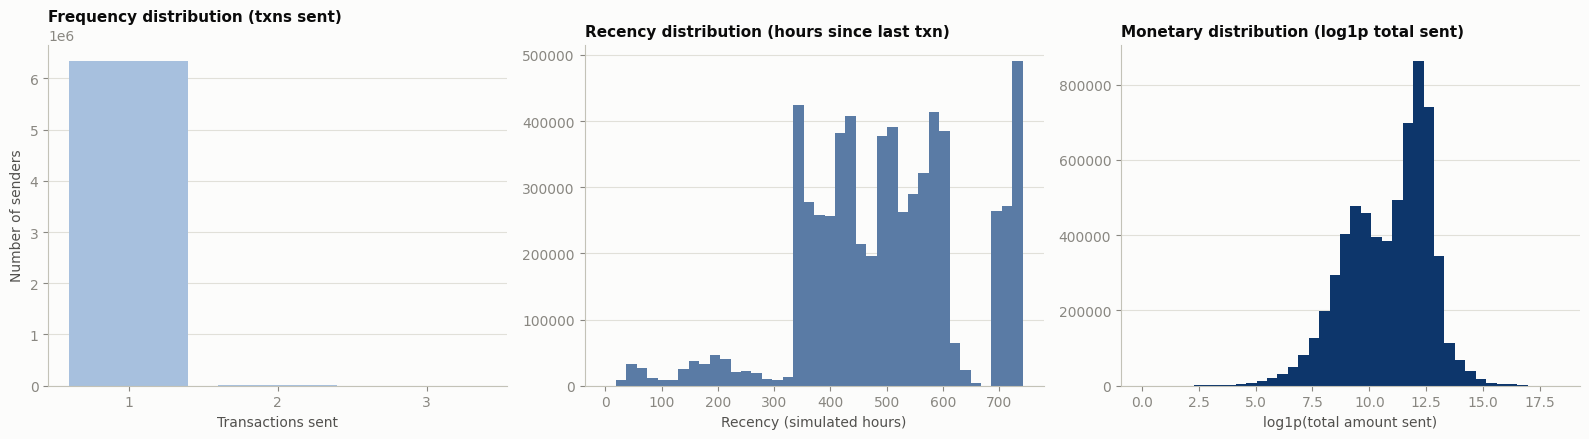

99.85% of senders send exactly 1 transaction; max frequency observed = 3.


In [3]:
freq_dist = rfm["frequency"].value_counts().sort_index()
freq_pct = (freq_dist / len(rfm) * 100).round(3)
display(pd.DataFrame({"n_senders": freq_dist, "pct_of_senders": freq_pct}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = sequential_shades(3)

axes[0].bar(freq_dist.index.astype(str), freq_dist.values, color=colors[0])
axes[0].set_title("Frequency distribution (txns sent)", loc="left", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Transactions sent")
axes[0].set_ylabel("Number of senders")
axes[0].grid(axis="x", visible=False)

axes[1].hist(rfm["recency_hours"], bins=40, color=colors[1])
axes[1].set_title("Recency distribution (hours since last txn)", loc="left", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Recency (simulated hours)")
axes[1].grid(axis="x", visible=False)

axes[2].hist(np.log1p(rfm["monetary"]), bins=40, color=colors[2])
axes[2].set_title("Monetary distribution (log1p total sent)", loc="left", fontsize=11, fontweight="bold")
axes[2].set_xlabel("log1p(total amount sent)")
axes[2].grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

print(f"{freq_pct.loc[1]:.2f}% of senders send exactly 1 transaction; "
      f"max frequency observed = {rfm['frequency'].max()}.")

## 3. Feature Engineering for Clustering

`cs.rfm_feature_matrix()` applies `log1p` to Frequency and Monetary (standard RFM practice for right-skewed
spend/count data) before standardizing all three features. The `log1p` on Frequency matters more here than
usual: with 99.85% of senders sitting at Frequency=1, raw standardization would blow the rare
Frequency=2/3 senders out to many standard deviations from the mean, letting a ~0.15% tail dominate cluster
assignment. `log1p(1)=0.69`, `log1p(2)=1.10`, `log1p(3)=1.39` compresses that gap to something K-Means can
reasonably work with instead of being wrecked by it.

In [4]:
X_scaled, scaler = cs.rfm_feature_matrix(rfm)
print(f"Feature matrix: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} columns")
X_scaled.describe().round(3)

Feature matrix: 6,353,307 rows x 3 columns


,recency_hours,frequency_log,monetary_log
count,6353307.000,6353307.000,6353307.000
mean,-0.000,0.000,0.000
std,1.000,1.000,1.000
min,-3.509,-0.038,-5.976
25%,-0.643,-0.038,-0.738
50%,0.032,-0.038,0.211
75%,0.615,-0.038,0.776
max,1.704,44.612,4.133


## 4. Choosing k — Elbow Method + Silhouette Score

`cs.elbow_silhouette_curve()` fits K-Means for k=2..10 on a fixed seeded sample (`RANDOM_STATE=42`) — full
pairwise silhouette computation is infeasible across millions of rows, and a representative sample is
standard practice for k-selection regardless of dataset size.

,k,inertia,silhouette
0,2,39592.2841,0.9331
1,3,25453.9868,0.3676
2,4,16771.5967,0.3702
3,5,13005.9282,0.3677
4,6,10506.9864,0.3852
5,7,8939.1081,0.3794
6,8,7477.4327,0.3893
7,9,6506.8309,0.3989
8,10,5837.8669,0.3827


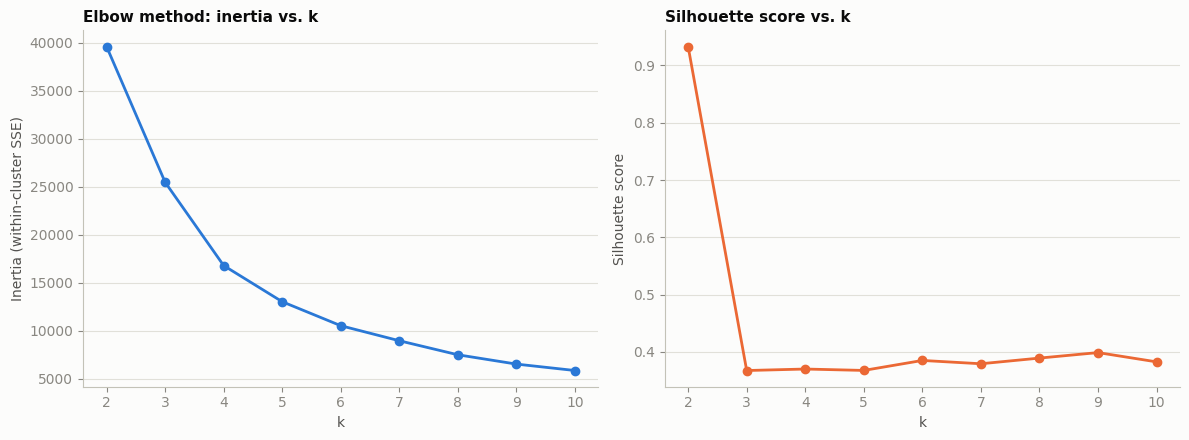

k with highest silhouette score: 2


In [5]:
curve = cs.elbow_silhouette_curve(X_scaled, k_range=range(2, 11), random_state=RANDOM_STATE)
display(curve.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(curve["k"], curve["inertia"], marker="o", color=SEQUENTIAL_BLUE, linewidth=2)
axes[0].set_title("Elbow method: inertia vs. k", loc="left", fontsize=11, fontweight="bold")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].grid(axis="x", visible=False)

axes[1].plot(curve["k"], curve["silhouette"], marker="o", color="#eb6834", linewidth=2)
axes[1].set_title("Silhouette score vs. k", loc="left", fontsize=11, fontweight="bold")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

best_silhouette_k = int(curve.loc[curve["silhouette"].idxmax(), "k"])
print(f"k with highest silhouette score: {best_silhouette_k}")

**Silhouette peaks at k=2 (0.933) — but this is not a useful segmentation, and picking it mechanically would
be a mistake.** Section 2 already flagged why: 9,298 customers (0.15%) sent 2-3 transactions while
6,344,009 (99.85%) sent exactly 1. A 2-cluster split's easiest win is to isolate that tiny, extreme-outlier
tail from everyone else — which is exactly what a direct k=2 fit does (cluster sizes 6,344,009 vs. 9,298,
matching the Section 2 frequency breakdown almost exactly). That's a real fact about repeat senders, but it
throws away all Recency/Monetary variation within the 99.85% "everyone else" bucket, which is where the
actual business-relevant behavioral differences live.

Excluding that degenerate global maximum, silhouette is essentially flat across k=3-10 (0.367-0.399, no
clear second peak), while the elbow curve's steepest drop in inertia happens between k=3 and k=5 before
flattening out noticeably from k=6 onward. **Chosen k=4** — at the elbow's knee, small enough to stay
business-readable, and large enough to let Recency and Monetary actually differentiate customers instead of
being swamped by the Frequency outlier signal. This mirrors the credit risk report's Section 5 framing: the
metric-optimal choice (k=2 here, the F2-optimal threshold there) isn't automatically the deployable one —
picking it requires the same judgment call, made explicit rather than silently defaulted to.

## 5. Fit Final K-Means

Final model fit on the **full** 6.35M-row scaled feature matrix (not just the k-selection sample) — with
only 3 low-dimensional features this is computationally cheap enough to do properly, so every customer's
segment comes from a model that actually saw their data, rather than being generalized from a sample fit.

In [6]:
# k=4: NOT the silhouette-maximizing k (that's the degenerate k=2 outlier-isolation split — see reasoning
# above). Chosen at the elbow's knee instead, a deliberate deployability call.
chosen_k = 4
print(f"Fitting final K-Means with k={chosen_k} on the full {len(X_scaled):,}-row feature matrix ...")

kmeans = cs.fit_kmeans(X_scaled, k=chosen_k, random_state=RANDOM_STATE)
rfm["cluster"] = kmeans.labels_
print("Done.")
rfm["cluster"].value_counts().sort_index()

Fitting final K-Means with k=4 on the full 6,353,307-row feature matrix ...


Done.


cluster
0    1994919
1       9298
2    2150804
3    2198286
Name: count, dtype: int64

## 6. Cluster Profiles & Business Labels

`cs.profile_clusters()` reports **raw, untransformed** average recency/frequency/monetary per cluster
(business-readable, not the log/scaled values clustering ran on). `cs.label_clusters()` splits clusters into
two different naming regimes:

- **Repeat-sender clusters** (avg. frequency meaningfully above the 1-transaction baseline) get
  RFM/loyalty-style language (`High-Value Loyal`) — that framing is earned there, since there's an actual
  repeat-transaction pattern behind it.
- **One-time clusters** (avg. frequency ~1, no second transaction to compare against) do **not** get
  trajectory language like "Lapsing"/"Dormant"/"New" — a single transaction has no trajectory, and Recency
  differences between one-time senders (which, per the notebook intro, are simulated-time to begin with)
  don't mean what "lapsing" implies for an actual repeat customer. One-time clusters are labeled purely on
  transaction size: `High-Value One-Time` / `Standard One-Time` / `Low-Value One-Time`, by relative rank on
  average monetary value among the one-time clusters.

,cluster,n_customers,avg_recency_hours,avg_frequency,avg_monetary,segment,pct_of_customers
0,0,1994919,526.88,1.0,9518.13,Low-Value One-Time,31.40
1,1,9298,422.49,2.0,366625.48,High-Value Loyal,0.15
2,2,2150804,364.53,1.0,249511.14,Standard One-Time,33.85
3,3,2198286,606.99,1.0,266274.09,High-Value One-Time,34.60


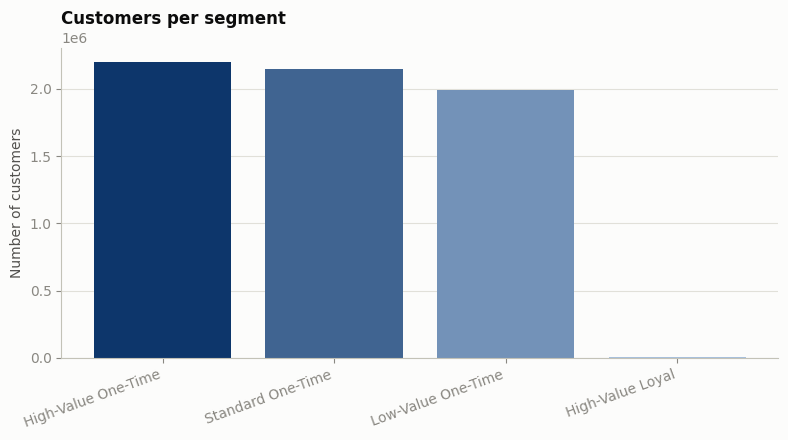

In [7]:
profile = cs.profile_clusters(rfm)
segment_labels = cs.label_clusters(profile)
profile["segment"] = profile["cluster"].map(segment_labels)
profile["pct_of_customers"] = (profile["n_customers"] / len(rfm) * 100).round(3)
display(profile.round(2))

rfm["segment"] = rfm["cluster"].map(segment_labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
order = profile.sort_values("n_customers", ascending=False)
colors = sequential_shades(len(order))[::-1]
ax.bar(order["segment"], order["n_customers"], color=colors)
ax.set_title("Customers per segment", loc="left", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of customers")
ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels():
    label.set_ha("right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 7. Cluster Scatter: Recency vs. Monetary (bubble = Frequency)

Plotting all 6.35M points would be unreadable (and slow) — a seeded random sample stands in for the full
population here, for visualization only (all 6.35M customers still get segmented and written back in
Section 8). Monetary is shown on a log axis given its heavy right skew (Section 2); bubble size scales with
Frequency, which given Section 2's finding will visually read as "almost every bubble is the same tiny
size, with a few larger ones for the rare repeat senders."

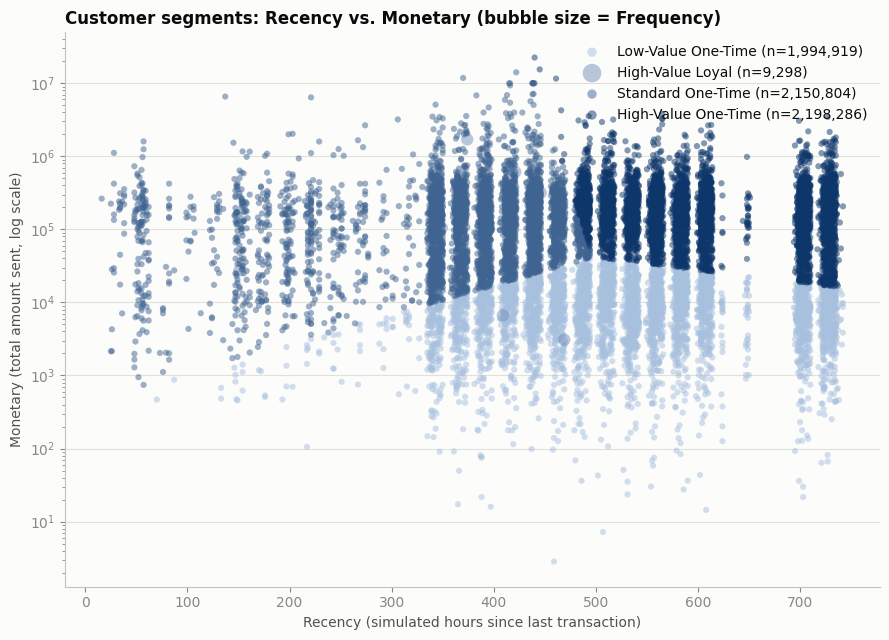

In [8]:
plot_sample = rfm.sample(n=min(15_000, len(rfm)), random_state=RANDOM_STATE)

cluster_order = profile.sort_values("cluster")["cluster"].tolist()
palette = dict(zip(cluster_order, sequential_shades(len(cluster_order))))

fig, ax = plt.subplots(figsize=(9, 6.5))
for cluster_id in cluster_order:
    sub = plot_sample[plot_sample["cluster"] == cluster_id]
    ax.scatter(
        sub["recency_hours"], sub["monetary"].clip(lower=1),
        s=20 + 60 * (sub["frequency"] - 1),  # frequency=1 (the vast majority) -> baseline bubble size
        alpha=0.5, color=palette[cluster_id], edgecolor="none",
        label=f"{segment_labels[cluster_id]} (n={len(rfm[rfm['cluster']==cluster_id]):,})",
    )

ax.set_yscale("log")
ax.set_xlabel("Recency (simulated hours since last transaction)")
ax.set_ylabel("Monetary (total amount sent, log scale)")
ax.set_title("Customer segments: Recency vs. Monetary (bubble size = Frequency)", loc="left",
              fontsize=12, fontweight="bold")
ax.legend(frameon=False, markerscale=1.5, loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 8. Write Back to `finsight.customers`

`cs.write_customers()` truncates and bulk-loads (`COPY`, same fast path as `db_connect.bulk_load` used for
loans/transactions/stock prices) every customer's RFM features and segment label. `risk_score` is left
`NULL` — it isn't derived by this notebook and populating it wasn't part of this analysis.

In [9]:
rfm["risk_score"] = np.nan
rows_written = cs.write_customers(engine, rfm)
print(f"Wrote {rows_written:,} rows to finsight.customers")

check = pd.read_sql("""
    SELECT segment, COUNT(*) AS n, ROUND(AVG(total_txn_value),2) AS avg_total_value
    FROM finsight.customers GROUP BY segment ORDER BY n DESC;
""", engine)
display(check)

Wrote 6,353,307 rows to finsight.customers


,segment,n,avg_total_value
0,High-Value One-Time,2198286,266274.09
1,Standard One-Time,2150804,249511.14
2,Low-Value One-Time,1994919,9518.13
3,High-Value Loyal,9298,366625.48


## Summary

**Population**: 6,353,307 distinct senders in `finsight.transactions`, RFM-aggregated and clustered with
K-Means (k=4, `RANDOM_STATE=42`), all written back to `finsight.customers`.

### Primary finding: 99.85% of this customer base is single-transaction, which caps what RFM segmentation
### can honestly claim to measure

Before reading any segment as a behavioral profile, the dominant fact about this population is that
6,344,009 of 6,353,307 senders (99.85%) transact exactly once (Section 2) — PaySim's simulated agents are
overwhelmingly one-shot, not a persistent customer base with realistic repeat behavior. That has two direct
consequences carried through the rest of this analysis:

- **k selection had to be a deliberate override, not a mechanical one.** Silhouette peaks at k=2, but that
  split just isolates the 0.15% repeat-sender tail from everyone else — a real fact, not a useful
  segmentation. k=4 was chosen at the elbow's knee instead (Section 4).
- **Three of the four segments below describe one-time senders, and are named accordingly.** They're split
  purely by transaction size (`High-Value One-Time` / `Standard One-Time` / `Low-Value One-Time`) rather
  than with trajectory language like "Lapsing" or "Dormant" — a single transaction has no trajectory to
  describe, and Recency differences among one-time senders are simulated-time artifacts (Section 4/6), not
  evidence of a customer disengaging.

| Segment | Customers | % | Avg. Recency (hrs) | Avg. Frequency | Avg. Monetary |
|---|---|---|---|---|---|
| High-Value One-Time | 2,198,286 | 34.60% | 606.99 | 1.0 | ₹266,274 |
| Standard One-Time | 2,150,804 | 33.85% | 364.53 | 1.0 | ₹249,511 |
| Low-Value One-Time | 1,994,919 | 31.40% | 526.88 | 1.0 | ₹9,518 |
| High-Value Loyal | 9,298 | 0.15% | 422.49 | 2.0 | ₹366,625 |

### Secondary finding: the 0.15% repeat-customer segment is small but genuinely earns RFM language

**High-Value Loyal** (9,298 customers, 0.15%) is the *only* cluster with real repeat-transaction behavior
(avg. frequency 2.0, vs. ~1.0 everywhere else) — and it also has the highest average spend of any segment.
This is the one place in the whole analysis where "loyal" is a defensible word rather than a borrowed CRM
label stretched over a single data point: there's an actual second transaction backing up the claim. Small
as it is in headcount, it's the natural candidate for a disproportionate share of retention/relationship
attention, precisely because it's the only segment where a repeat relationship is demonstrably real.

**Two limitations to carry forward, not hide**:
1. **Recency is simulated-time**, not real calendar time — hours relative to the dataset's own end
   (`step` 1-743), not an actual customer's real-world lapse. Even for the one-time segments' descriptive
   Recency figures above, this should be read as "position within a 31-day simulation window," not
   calendar-accurate.
2. **This dataset can't really support a Frequency-driven segmentation.** With 99.85% of senders one-shot,
   most of what distinguishes segments here is transaction size, not behavior over time. On a real
   transaction log with genuine repeat customers, Frequency — and legitimate trajectory language built on
   it — would carry much more of the segmentation's information content than it does here.